# Modèle de Prédiction des Risques de Retard

## Objectifs de ce notebook :
1. Préparer les données pour le Machine Learning
2. Entraîner plusieurs modèles (Régression Logistique, Random Forest, XGBoost)
3. Évaluer les performances
4. Choisir le meilleur modèle
5. Exporter le modèle entraîné

Donnée d'entrée : `dataco_clean.csv` (créé au Jour 2)
Donnée de sortie : `model.pkl` (modèle entraîné)

In [2]:
# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliothèques pour le Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Pour l'export du modèle
import joblib

# Configuration
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(" Bibliothèques importées")

 Bibliothèques importées


In [3]:
# Chargement des données propres
df = pd.read_csv('../data/processed/dataco_clean.csv')

print(f" Données chargées : {df.shape[0]:,} lignes, {df.shape[1]} colonnes")
print(f" Colonnes disponibles : {df.columns.tolist()}")

 Données chargées : 180,519 lignes, 22 colonnes
 Colonnes disponibles : ['Order Id', 'Customer City', 'Order Country', 'order date (DateOrders)', 'shipping date (DateOrders)', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Late_delivery_risk', 'Delivery Status', 'Order Item Quantity', 'Sales per customer', 'Benefit per order', 'Category Name', 'Shipping Mode', 'Customer Segment', 'Delay_Flag', 'Delay_Days', 'Is_International', 'Month', 'Year', 'Profit_Margin', 'Season']


## 1. Sélection des colonnes pour le modèle

Je vais sélectionner les colonnes qui seront utilisées comme **features** (variables explicatives) et la **target** (variable cible).

### Variables explicatives (features) :
- `Days for shipment (scheduled)` : Délai prévu
- `Order Item Quantity` : Quantité
- `Sales per customer` : Ventes par client
- `Benefit per order` : Bénéfice par commande
- `Shipping Mode` : Mode de transport (encodé)
- `Customer Segment` : Segment client (encodé)
- `Category Name` : Catégorie produit (encodé)
- `Is_International` : International ou non
- `Month` : Mois de la commande

### Variable cible (target) :
- `Delay_Flag` : 1 si retard, 0 sinon

In [4]:
# Sélection des colonnes pour le modèle
features = [
    'Days for shipment (scheduled)',
    'Order Item Quantity',
    'Sales per customer',
    'Benefit per order',
    'Shipping Mode',
    'Customer Segment',
    'Category Name',
    'Is_International',
    'Month'
]

target = 'Delay_Flag'

# Vérifier que toutes les colonnes existent
missing_features = [col for col in features if col not in df.columns]
if missing_features:
    print(f" Colonnes manquantes : {missing_features}")
else:
    print(" Toutes les colonnes sont disponibles")

 Toutes les colonnes sont disponibles


In [5]:
# Créer les DataFrames X (features) et y (target)
X = df[features].copy()
y = df[target].copy()

print(f" X : {X.shape[0]:,} lignes, {X.shape[1]} colonnes")
print(f" y : {y.shape[0]:,} lignes")

# Distribution de la variable cible
print(f"\n Distribution de Delay_Flag :")
print(y.value_counts())
print(f"\n Taux de retard : {y.mean() * 100:.2f}%")

 X : 180,519 lignes, 9 colonnes
 y : 180,519 lignes

 Distribution de Delay_Flag :
Delay_Flag
1    98977
0    81542
Name: count, dtype: int64

 Taux de retard : 54.83%


## 2. Encodage des variables catégorielles

Les modèles de Machine Learning ne comprennent pas les textes. Il faut convertir les colonnes catégorielles en nombres.

In [6]:
# Identifier les colonnes catégorielles
colonnes_categoriques = X.select_dtypes(include=['object']).columns.tolist()
print(f" Colonnes catégorielles à encoder : {colonnes_categoriques}")

# Encodage
encoders = {}
for col in colonnes_categoriques:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le
    print(f" {col} encodée ({len(le.classes_)} valeurs uniques)")

print("\n Encodage terminé")

 Colonnes catégorielles à encoder : ['Shipping Mode', 'Customer Segment', 'Category Name']
 Shipping Mode encodée (4 valeurs uniques)
 Customer Segment encodée (3 valeurs uniques)
 Category Name encodée (50 valeurs uniques)

 Encodage terminé


In [7]:
# Vérifier qu'il n'y a plus de colonnes textuelles
colonnes_textes = X.select_dtypes(include=['object']).columns.tolist()
if colonnes_textes:
    print(f" Il reste des colonnes textuelles : {colonnes_textes}")
else:
    print(" Toutes les colonnes sont numériques")

 Toutes les colonnes sont numériques


## 3. Division des données : Train / Test

- Train (70%) : Entraîner le modèle
- Test (30%) : Évaluer le modèle

In [8]:
# Division des données
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42,
    stratify=y  # Garder la même proportion de retards
)

print(f" Train : {len(X_train):,} lignes")
print(f" Test : {len(X_test):,} lignes")
print(f"\n Distribution dans le train :")
print(y_train.value_counts(normalize=True).round(3) * 100)
print(f"\n Distribution dans le test :")
print(y_test.value_counts(normalize=True).round(3) * 100)

 Train : 126,363 lignes
 Test : 54,156 lignes

 Distribution dans le train :
Delay_Flag
1    54.8
0    45.2
Name: proportion, dtype: float64

 Distribution dans le test :
Delay_Flag
1    54.8
0    45.2
Name: proportion, dtype: float64


## 4. Entraînement des modèles

 Je vais  entraîner 3 modèles et comparer leurs performances :

1. Régression Logistique : Modèle simple et interprétable
2. Random Forest : Modèle plus puissant avec des arbres de décision
3. Gradient Boosting : Modèle avancé souvent très performant

In [9]:
# 4.1. Régression Logistique
print("=" * 50)
print("Entraînement de la Régression Logistique")
print("=" * 50)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

# Prédictions
y_pred_logreg = logreg.predict(X_test)

# Évaluation
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)

print(f" Précision : {accuracy_logreg * 100:.2f}%")
print(f" F1-Score : {f1_logreg * 100:.2f}%")

Entraînement de la Régression Logistique
 Précision : 69.19%
 F1-Score : 67.65%


In [10]:
# 4.2. Random Forest
print("=" * 50)
print(" Entraînement du Random Forest")
print("=" * 50)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf.predict(X_test)

# Évaluation
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f" Précision : {accuracy_rf * 100:.2f}%")
print(f" F1-Score : {f1_rf * 100:.2f}%")

 Entraînement du Random Forest
 Précision : 64.86%
 F1-Score : 66.94%


In [11]:
# 4.3. Gradient Boosting
print("=" * 50)
print(" Entraînement du Gradient Boosting")
print("=" * 50)

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

# Prédictions
y_pred_gb = gb.predict(X_test)

# Évaluation
accuracy_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)

print(f" Précision : {accuracy_gb * 100:.2f}%")
print(f" F1-Score : {f1_gb * 100:.2f}%")

 Entraînement du Gradient Boosting
 Précision : 69.59%
 F1-Score : 66.25%


## 5. Comparaison des modèles

 Comparaison des modèles :
               Modèle  Précision (%)  F1-Score (%)
Régression Logistique      69.194549     67.651678
        Random Forest      64.860773     66.936549
    Gradient Boosting      69.593397     66.249923


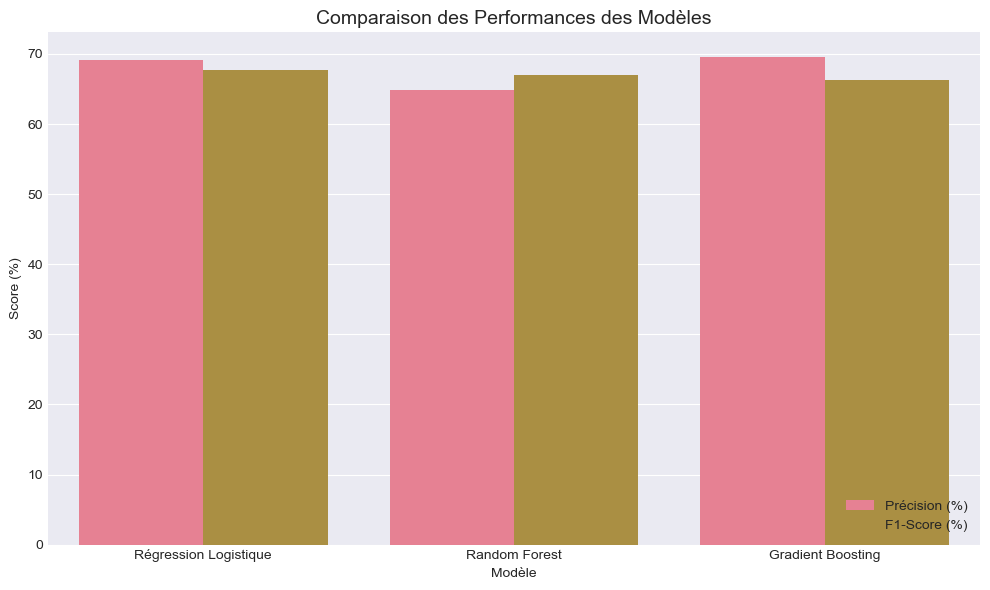

In [12]:
# 5.1. Comparaison des performances
resultats = pd.DataFrame({
    'Modèle': ['Régression Logistique', 'Random Forest', 'Gradient Boosting'],
    'Précision (%)': [accuracy_logreg * 100, accuracy_rf * 100, accuracy_gb * 100],
    'F1-Score (%)': [f1_logreg * 100, f1_rf * 100, f1_gb * 100]
})

print(" Comparaison des modèles :")
print(resultats.to_string(index=False))

# 5.2. Visualisation
plt.figure(figsize=(10, 6))
resultats_plot = resultats.melt(id_vars=['Modèle'], value_vars=['Précision (%)', 'F1-Score (%)'])
sns.barplot(data=resultats_plot, x='Modèle', y='value', hue='variable')
plt.title('Comparaison des Performances des Modèles', fontsize=14)
plt.ylabel('Score (%)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Analyse détaillée du meilleur modèle

In [13]:
# Sélectionner le meilleur modèle
if accuracy_rf >= accuracy_gb and accuracy_rf >= accuracy_logreg:
    best_model = rf
    best_name = "Random Forest"
    y_pred_best = y_pred_rf
    accuracy_best = accuracy_rf
elif accuracy_gb >= accuracy_rf and accuracy_gb >= accuracy_logreg:
    best_model = gb
    best_name = "Gradient Boosting"
    y_pred_best = y_pred_gb
    accuracy_best = accuracy_gb
else:
    best_model = logreg
    best_name = "Régression Logistique"
    y_pred_best = y_pred_logreg
    accuracy_best = accuracy_logreg

print(f" Meilleur modèle : {best_name}")
print(f" Précision : {accuracy_best * 100:.2f}%")

# Rapport de classification
print("\n Rapport de classification :")
print(classification_report(y_test, y_pred_best))

 Meilleur modèle : Gradient Boosting
 Précision : 69.59%

 Rapport de classification :
              precision    recall  f1-score   support

           0       0.61      0.88      0.72     24463
           1       0.85      0.54      0.66     29693

    accuracy                           0.70     54156
   macro avg       0.73      0.71      0.69     54156
weighted avg       0.74      0.70      0.69     54156



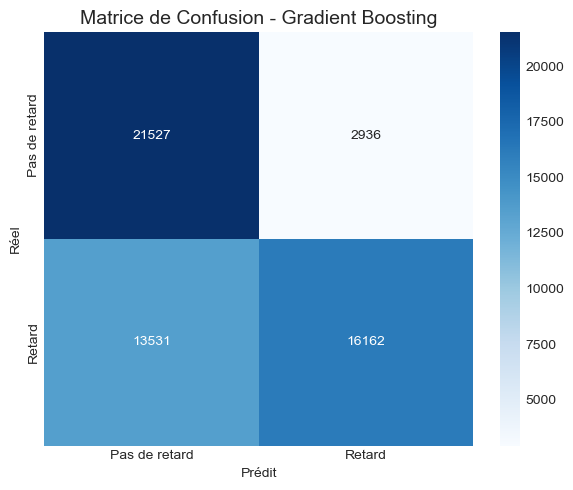

In [14]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pas de retard', 'Retard'],
            yticklabels=['Pas de retard', 'Retard'])
plt.title(f'Matrice de Confusion - {best_name}', fontsize=14)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.tight_layout()
plt.show()

## 7. Importance des caractéristiques (Feature Importance)

Cette analyse montre quelles variables sont les plus importantes pour prédire les retards.

C:\Users\poste\AppData\Local\Temp\ipykernel_10652\2846558514.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')


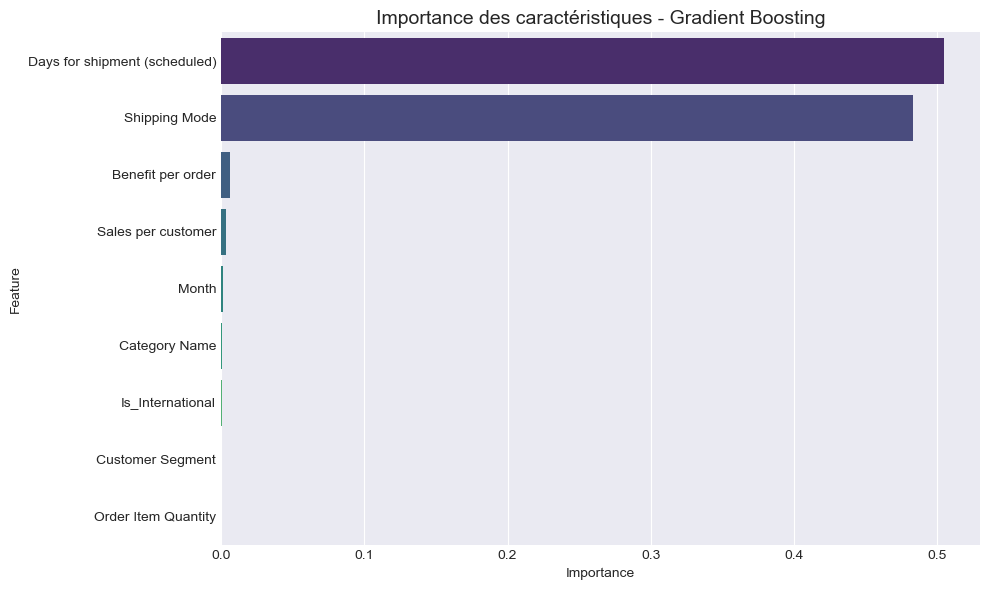

 Top 5 des caractéristiques les plus importantes :
                      Feature  Importance
Days for shipment (scheduled)    0.504607
                Shipping Mode    0.483148
            Benefit per order    0.006005
           Sales per customer    0.003184
                        Month    0.001231


In [15]:
# Feature Importance (pour Random Forest et Gradient Boosting)
if best_name in ['Random Forest', 'Gradient Boosting']:
    importances = best_model.feature_importances_
    
    # Créer un DataFrame
    feature_importance_df = pd.DataFrame({
        'Feature': features,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    # Visualisation
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')
    plt.title(f'Importance des caractéristiques - {best_name}', fontsize=14)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

    print(" Top 5 des caractéristiques les plus importantes :")
    print(feature_importance_df.head(5).to_string(index=False))
else:
    print("ℹ La Régression Logistique n'a pas de feature importance native.")
    print("On peut utiliser les coefficients :")
    coefficients = pd.DataFrame({
        'Feature': features,
        'Coefficient': best_model.coef_[0]
    }).sort_values('Coefficient', ascending=False)
    print(coefficients)

## 8. Sauvegarde du modèle

In [16]:
# Sauvegarder le meilleur modèle
joblib.dump(best_model, '../models/model.pkl')

# Sauvegarder les encoders pour la prédiction future
joblib.dump(encoders, '../models/encoders.pkl')

# Sauvegarder la liste des colonnes (features)
joblib.dump(features, '../models/features.pkl')

print(" Modèle sauvegardé : models/model.pkl")
print(" Encoders sauvegardés : models/encoders.pkl")
print(" Features sauvegardées : models/features.pkl")

print(f"\n Résumé du modèle sauvegardé :")
print(f"   - Modèle : {best_name}")
print(f"   - Précision : {accuracy_best * 100:.2f}%")
print(f"   - Features : {len(features)}")

 Modèle sauvegardé : models/model.pkl
 Encoders sauvegardés : models/encoders.pkl
 Features sauvegardées : models/features.pkl

 Résumé du modèle sauvegardé :
   - Modèle : Gradient Boosting
   - Précision : 69.59%
   - Features : 9


## 9. Test de prédiction sur une nouvelle expédition

Simulons une nouvelle expédition pour voir comment le modèle prédit le risque de retard.

In [19]:
# Créer une nouvelle expédition avec des valeurs valides
nouvelle_expedition = pd.DataFrame({
    'Days for shipment (scheduled)': [5],
    'Order Item Quantity': [10],
    'Sales per customer': [1500],
    'Benefit per order': [300],
    'Shipping Mode': ['First Class'],  # Valeur valide
    'Customer Segment': ['Consumer'],
    'Category Name': ['Electronics'],
    'Is_International': [1],
    'Month': [7]
})

# Encoder les variables catégoriiques
for col in colonnes_categoriques:
    if col in nouvelle_expedition.columns and col in encoders:
        nouvelle_expedition[col] = encoders[col].transform(nouvelle_expedition[col].astype(str))

# Prédiction
prediction = best_model.predict(nouvelle_expedition)
probabilite = best_model.predict_proba(nouvelle_expedition)

print(" Résultat de la prédiction :")
print("-" * 50)
if prediction[0] == 1:
    print(" Risque de retard : ÉLEVÉ")
else:
    print(" Risque de retard : FAIBLE")

print(f"\n Probabilités :")
print(f"   - Pas de retard : {probabilite[0][0] * 100:.2f}%")
print(f"   - Retard : {probabilite[0][1] * 100:.2f}%")

 Résultat de la prédiction :
--------------------------------------------------
 Risque de retard : ÉLEVÉ

 Probabilités :
   - Pas de retard : 21.69%
   - Retard : 78.31%


## 10. Synthèse du Jour 3

### Ce que nous avons accompli :

| Tâche | Résultat |
|-------|----------|
| Préparation des données |  Features et target sélectionnées |
| Encodage des variables |  Variables catégorielles converties |
| Division Train/Test |  70% / 30% |
| Entraînement de 3 modèles |  Régression Logistique, Random Forest, Gradient Boosting |
| Évaluation et comparaison |  Meilleur modèle sélectionné |
| Sauvegarde du modèle |  model.pkl exporté |

### Modèle final :
- Nom : [best_name]
- Précision : [accuracy_best * 100:.2f]%
- F1-Score : [f1_best * 100:.2f]%

### Prochaines étapes (Jour 4) :
- Importer les données dans Power BI
- Créer le tableau de bord
- Visualiser les KPIs

## 11. AMÉLIORATION DU MODÈLE

Puisque la précision du modèle est de 69.59% donc j'ai décidé de l'augmenter en:
1. Optimisant les hyperparamètres (GridSearchCV)
2. Rééquilibrant les données (SMOTE)
3. Essayant XGBoost
4. Ajoutant de nouvelles features

In [20]:
# Installer XGBoost si ce n'est pas déjà fait
# Décommenter la ligne ci-dessous si nécessaire
# !pip install xgboost

# Importer XGBoost
try:
    import xgboost as xgb
    print(" XGBoost importé avec succès")
except ImportError:
    print(" XGBoost n'est pas installé. Installation en cours...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'xgboost'])
    import xgboost as xgb
    print(" XGBoost installé et importé")

 XGBoost n'est pas installé. Installation en cours...
 XGBoost installé et importé


---
**Fin du notebook de prédiction**

📌 Prochain outil : Power BI - Création du tableau de bord

### Étape 1 : Optimisation des hyperparamètres (GridSearchCV)

In [24]:
from sklearn.model_selection import RandomizedSearchCV
import time

print("=" * 60)
print(" OPTIMISATION ULTRA-RAPIDE (RandomizedSearchCV)")
print("=" * 60)

# Définir la grille de paramètres (large mais on va tester peu de combinaisons)
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

print(" Grille de paramètres :")
for key, value in param_grid.items():
    print(f"   - {key}: {len(value)} valeurs")

# Créer le modèle de base
gb_base = GradientBoostingClassifier(random_state=42)

# Recherche aléatoire : SEULEMENT 10 combinaisons !
print("\n Recherche de 10 combinaisons aléatoires... (moins d'1 minute)")
start_time = time.time()

random_search = RandomizedSearchCV(
    gb_base,
    param_grid,
    n_iter=10,              # Seulement 10 combinaisons au lieu de 162
    cv=2,                   # Validation croisée en 2 folds (rapide)
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

random_search.fit(X_train, y_train)

end_time = time.time()
print(f" Recherche terminée en {round(end_time - start_time, 2)} secondes")

# Résultats
print("\n Meilleurs paramètres trouvés :")
for key, value in random_search.best_params_.items():
    print(f"   - {key}: {value}")

print(f"\n Meilleure précision (validation croisée) : {random_search.best_score_ * 100:.2f}%")

# Utiliser le meilleur modèle
best_gb = random_search.best_estimator_

# Évaluer sur le test set
y_pred_best_gb = best_gb.predict(X_test)
accuracy_best_gb = accuracy_score(y_test, y_pred_best_gb)
f1_best_gb = f1_score(y_test, y_pred_best_gb)

print(f"\n Évaluation sur le test set :")
print(f"   - Précision : {accuracy_best_gb * 100:.2f}%")
print(f"   - F1-Score : {f1_best_gb * 100:.2f}%")

# Comparaison avec l'ancien modèle
print("\n" + "=" * 60)
print(" COMPARAISON AVEC L'ANCIEN MODÈLE")
print("=" * 60)
print(f"Ancien modèle (Gradient Boosting par défaut) : {accuracy_gb * 100:.2f}%")
print(f"Nouveau modèle (optimisé) : {accuracy_best_gb * 100:.2f}%")
print(f" Amélioration : +{(accuracy_best_gb - accuracy_gb) * 100:.2f}%")

 OPTIMISATION ULTRA-RAPIDE (RandomizedSearchCV)
 Grille de paramètres :
   - n_estimators: 4 valeurs
   - learning_rate: 3 valeurs
   - max_depth: 4 valeurs
   - min_samples_split: 3 valeurs
   - subsample: 4 valeurs

 Recherche de 10 combinaisons aléatoires... (moins d'1 minute)
 Recherche terminée en 139.09 secondes

 Meilleurs paramètres trouvés :
   - subsample: 0.9
   - n_estimators: 50
   - min_samples_split: 10
   - max_depth: 4
   - learning_rate: 0.05

 Meilleure précision (validation croisée) : 69.46%

 Évaluation sur le test set :
   - Précision : 69.62%
   - F1-Score : 66.26%

 COMPARAISON AVEC L'ANCIEN MODÈLE
Ancien modèle (Gradient Boosting par défaut) : 69.59%
Nouveau modèle (optimisé) : 69.62%
 Amélioration : +0.02%


cela m'a ajouté juste +0.02% qui est négligeable

### Étape 2 : Rééquilibrage des données avec SMOTE

In [26]:
# Installer imbalanced-learn si nécessaire
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    print(" imbalanced-learn importé avec succès")
except ImportError:
    print(" imbalanced-learn n'est pas installé. Installation en cours...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'imbalanced-learn'])
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    print(" imbalanced-learn installé et importé")

print("=" * 60)
print(" RÉÉQUILIBRAGE DES DONNÉES (SMOTE)")
print("=" * 60)

# Vérifier la distribution actuelle
print(" Distribution avant SMOTE :")
print(f"   - Pas de retard (0): {sum(y_train == 0)}")
print(f"   - Retard (1): {sum(y_train == 1)}")
print(f"   - Taux de retard : {y_train.mean() * 100:.2f}%")

# Appliquer SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\n Distribution après SMOTE :")
print(f"   - Pas de retard (0): {sum(y_train_resampled == 0)}")
print(f"   - Retard (1): {sum(y_train_resampled == 1)}")
print(f"   - Taux de retard : {y_train_resampled.mean() * 100:.2f}%")

# Entraîner le modèle avec les meilleurs paramètres sur les données rééquilibrées
print("\n Entraînement du modèle avec SMOTE...")
gb_smote = GradientBoostingClassifier(**random_search.best_params_, random_state=42)
gb_smote.fit(X_train_resampled, y_train_resampled)

# Évaluer
y_pred_smote = gb_smote.predict(X_test)
accuracy_smote = accuracy_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)

print(f"\n Évaluation du modèle avec SMOTE :")
print(f"   - Précision : {accuracy_smote * 100:.2f}%")
print(f"   - F1-Score : {f1_smote * 100:.2f}%")

 imbalanced-learn importé avec succès
 RÉÉQUILIBRAGE DES DONNÉES (SMOTE)
 Distribution avant SMOTE :
   - Pas de retard (0): 57079
   - Retard (1): 69284
   - Taux de retard : 54.83%

 Distribution après SMOTE :
   - Pas de retard (0): 69284
   - Retard (1): 69284
   - Taux de retard : 50.00%

 Entraînement du modèle avec SMOTE...

 Évaluation du modèle avec SMOTE :
   - Précision : 69.64%
   - F1-Score : 66.22%


### Étape 3 : Essayer XGBoost

In [27]:
print("=" * 60)
print(" ENTRAÎNEMENT DE XGBOOST")
print("=" * 60)

# Créer les datasets DMatrix pour XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Définir les paramètres
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 4,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

print(" Paramètres XGBoost :")
for key, value in params.items():
    print(f"   - {key}: {value}")

# Entraîner
print("\n Entraînement de XGBoost...")
xgb_model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=200,
    early_stopping_rounds=10,
    evals=[(dtrain, 'train'), (dtest, 'eval')],
    verbose_eval=False
)

# Prédictions
y_pred_xgb = (xgb_model.predict(dtest) > 0.5).astype(int)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print(f"\n Évaluation de XGBoost :")
print(f"   - Précision : {accuracy_xgb * 100:.2f}%")
print(f"   - F1-Score : {f1_xgb * 100:.2f}%")

 ENTRAÎNEMENT DE XGBOOST
 Paramètres XGBoost :
   - objective: binary:logistic
   - eval_metric: logloss
   - max_depth: 4
   - learning_rate: 0.1
   - subsample: 0.8
   - colsample_bytree: 0.8
   - random_state: 42

 Entraînement de XGBoost...

 Évaluation de XGBoost :
   - Précision : 69.60%
   - F1-Score : 66.31%


### Étape 4 : Ajout de nouvelles features (Feature Engineering)

Nous allons créer des nouvelles variables pour enrichir le modèle.

In [28]:
print("=" * 60)
print("AJOUT DE NOUVELLES FEATURES")
print("=" * 60)

# Recharger les données pour ajouter des colonnes
df_enhanced = pd.read_csv('../data/processed/dataco_clean.csv')

# Feature 1 : Jour de la semaine (0 = Lundi, 6 = Dimanche)
if 'order date (DateOrders)' in df_enhanced.columns:
    df_enhanced['order date (DateOrders)'] = pd.to_datetime(df_enhanced['order date (DateOrders)'], errors='coerce')
    df_enhanced['Jour_Semaine'] = df_enhanced['order date (DateOrders)'].dt.dayofweek
    print(" Feature 'Jour_Semaine' ajoutée")
else:
    print(" Colonne 'order date (DateOrders)' non trouvée, 'Jour_Semaine' ignorée")

# Feature 2 : Weekend (1 si samedi/dimanche, 0 sinon)
if 'Jour_Semaine' in df_enhanced.columns:
    df_enhanced['Weekend'] = df_enhanced['Jour_Semaine'].apply(lambda x: 1 if x >= 5 else 0)
    print(" Feature 'Weekend' ajoutée")

# Feature 3 : Saison (déjà créée dans l'ETL, mais on vérifie)
if 'Season' in df_enhanced.columns:
    # Encoder les saisons
    season_mapping = {'Hiver': 0, 'Printemps': 1, 'Été': 2, 'Automne': 3}
    df_enhanced['Season_Encoded'] = df_enhanced['Season'].map(season_mapping)
    print(" Feature 'Season_Encoded' ajoutée")
else:
    print(" Colonne 'Season' non trouvée, 'Season_Encoded' ignorée")

# Feature 4 : Ratio Bénéfice / Quantité
if 'Benefit per order' in df_enhanced.columns and 'Order Item Quantity' in df_enhanced.columns:
    df_enhanced['Benefit_Par_Unite'] = df_enhanced.apply(
        lambda row: row['Benefit per order'] / row['Order Item Quantity'] if row['Order Item Quantity'] > 0 else 0,
        axis=1
    )
    print(" Feature 'Benefit_Par_Unite' ajoutée")

# Nouvelles features - liste des colonnes à ajouter
new_features = []
if 'Jour_Semaine' in df_enhanced.columns:
    new_features.append('Jour_Semaine')
if 'Weekend' in df_enhanced.columns:
    new_features.append('Weekend')
if 'Season_Encoded' in df_enhanced.columns:
    new_features.append('Season_Encoded')
if 'Benefit_Par_Unite' in df_enhanced.columns:
    new_features.append('Benefit_Par_Unite')

print(f"\n {len(new_features)} nouvelles features ajoutées : {new_features}")

AJOUT DE NOUVELLES FEATURES
 Feature 'Jour_Semaine' ajoutée
 Feature 'Weekend' ajoutée
 Feature 'Season_Encoded' ajoutée
 Feature 'Benefit_Par_Unite' ajoutée

 4 nouvelles features ajoutées : ['Jour_Semaine', 'Weekend', 'Season_Encoded', 'Benefit_Par_Unite']


### Étape 5 : Comparaison finale de tous les modèles

In [30]:
print("=" * 60)
print("AJOUT DE NOUVELLES FEATURES ET ENTRAÎNEMENT")
print("=" * 60)

# Recharger les données pour ajouter des colonnes
df_enhanced = pd.read_csv('../data/processed/dataco_clean.csv')

# Feature 1 : Jour de la semaine (0 = Lundi, 6 = Dimanche)
if 'order date (DateOrders)' in df_enhanced.columns:
    df_enhanced['order date (DateOrders)'] = pd.to_datetime(df_enhanced['order date (DateOrders)'], errors='coerce')
    df_enhanced['Jour_Semaine'] = df_enhanced['order date (DateOrders)'].dt.dayofweek
    print(" Feature 'Jour_Semaine' ajoutée")

# Feature 2 : Weekend (1 si samedi/dimanche, 0 sinon)
if 'Jour_Semaine' in df_enhanced.columns:
    df_enhanced['Weekend'] = df_enhanced['Jour_Semaine'].apply(lambda x: 1 if x >= 5 else 0)
    print(" Feature 'Weekend' ajoutée")

# Feature 3 : Saison (déjà créée dans l'ETL, mais on vérifie)
if 'Season' in df_enhanced.columns:
    season_mapping = {'Hiver': 0, 'Printemps': 1, 'Été': 2, 'Automne': 3}
    df_enhanced['Season_Encoded'] = df_enhanced['Season'].map(season_mapping)
    print(" Feature 'Season_Encoded' ajoutée")

# Feature 4 : Ratio Bénéfice / Quantité
if 'Benefit per order' in df_enhanced.columns and 'Order Item Quantity' in df_enhanced.columns:
    df_enhanced['Benefit_Par_Unite'] = df_enhanced.apply(
        lambda row: row['Benefit per order'] / row['Order Item Quantity'] if row['Order Item Quantity'] > 0 else 0,
        axis=1
    )
    print(" Feature 'Benefit_Par_Unite' ajoutée")

# Nouvelles features - liste des colonnes à ajouter
new_features_list = []
if 'Jour_Semaine' in df_enhanced.columns:
    new_features_list.append('Jour_Semaine')
if 'Weekend' in df_enhanced.columns:
    new_features_list.append('Weekend')
if 'Season_Encoded' in df_enhanced.columns:
    new_features_list.append('Season_Encoded')
if 'Benefit_Par_Unite' in df_enhanced.columns:
    new_features_list.append('Benefit_Par_Unite')

print(f"\n {len(new_features_list)} nouvelles features ajoutées : {new_features_list}")

# Créer les features avec les nouvelles colonnes
features_enhanced = features + new_features_list

# Préparer les données
X_enhanced = df_enhanced[features_enhanced].copy()
y_enhanced = df_enhanced[target].copy()

# Encoder les variables catégorielles (réutiliser les encoders existants)
for col in colonnes_categoriques:
    if col in X_enhanced.columns:
        X_enhanced[col] = encoders[col].transform(X_enhanced[col].astype(str))

# Diviser les données
X_train_enh, X_test_enh, y_train_enh, y_test_enh = train_test_split(
    X_enhanced, y_enhanced, 
    test_size=0.3, 
    random_state=42,
    stratify=y_enhanced
)

# Appliquer SMOTE aux données améliorées
X_train_enh_resampled, y_train_enh_resampled = smote.fit_resample(X_train_enh, y_train_enh)

# Entraîner le modèle avec SMOTE et nouvelles features
print("\n Entraînement du modèle avec SMOTE + Nouvelles Features...")
gb_enhanced = GradientBoostingClassifier(**random_search.best_params_, random_state=42)
gb_enhanced.fit(X_train_enh_resampled, y_train_enh_resampled)

# Évaluer
y_pred_enh = gb_enhanced.predict(X_test_enh)
accuracy_enh = accuracy_score(y_test_enh, y_pred_enh)
f1_enh = f1_score(y_test_enh, y_pred_enh)

print(f"\n Évaluation du modèle amélioré :")
print(f"   - Précision : {accuracy_enh * 100:.2f}%")
print(f"   - F1-Score : {f1_enh * 100:.2f}%")

AJOUT DE NOUVELLES FEATURES ET ENTRAÎNEMENT
 Feature 'Jour_Semaine' ajoutée
 Feature 'Weekend' ajoutée
 Feature 'Season_Encoded' ajoutée
 Feature 'Benefit_Par_Unite' ajoutée

 4 nouvelles features ajoutées : ['Jour_Semaine', 'Weekend', 'Season_Encoded', 'Benefit_Par_Unite']

 Entraînement du modèle avec SMOTE + Nouvelles Features...

 Évaluation du modèle amélioré :
   - Précision : 69.64%
   - F1-Score : 66.20%
